# Pour le quatrième et dernier pipeline, je voulais vérifier si la technique d’embedding influence les performances du modèle. J’ai donc utilisé Word2Vec pour générer les embeddings.

In [1]:
import pandas as pd
import regex as re
import contractions
import spacy

In [2]:
raw = pd.read_csv("../IMDB Dataset.csv")
raw = raw.drop_duplicates(subset='review', keep='first')

In [3]:
raw

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


# Prétraitement


In [4]:
raw[raw['review'].str.contains(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')]

,review,sentiment
1281,I like many others saw this as a child and I l...,positive
3568,I have noticed that people have asked if anyon...,positive
5068,Brilliant adaptation of the largely interior m...,positive
8176,I could never remember the name of this show. ...,positive
8474,I'm like the rest of the fans who love this co...,positive
9510,I cant believe how many excellent actors can b...,positive
9978,I really can't say too much more about the plo...,positive
12166,Robert Jordan is a television star. Robert Jor...,positive
13471,This movie was everything but boring. It deals...,positive
13741,I LOVE this movie. and Disney channel is ridic...,positive


In [5]:
cleaning = raw.copy()

In [6]:
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' ', x))
cleaning["review"] = cleaning["review"].apply(lambda x: re.sub(r"<.*?>", "", x))
cleaning["review"] = cleaning["review"].apply(lambda x: x.lower())
cleaning["review"] = cleaning["review"].apply(lambda x: contractions.fix(x))
nlp = spacy.load("en_core_web_sm")
cleaning["review"] = cleaning["review"].apply(lambda x: " ".join(token.lemma_ for token in nlp(x)))


In [7]:
cleaning["label"] = cleaning["sentiment"] == "positive"

In [8]:
cleaned = cleaning[["review", "label"]].copy()

# Tokenization & vectorization

In [9]:
import numpy as np
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [10]:
# Tokenize the reviews (split into words)
cleaned["tokens"] = cleaned["review"].apply(lambda x: x.split())

# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=cleaned["tokens"].tolist(),
    vector_size=100,  # Embedding dimension
    window=5,         # Context window
    min_count=2,      # Ignore words with frequency less than this
    workers=4,
    epochs=10
)

In [11]:
# Create word-to-index mapping
vocab = word2vec_model.wv.key_to_index
vocab_size = len(vocab) + 1  # +1 for padding token

In [12]:
vocab_size

60089

In [13]:
# Create embedding matrix
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, idx in vocab.items():
    embedding_matrix[idx] = word2vec_model.wv[word]

In [14]:
embedding_matrix

array([[-1.36772847e+00,  9.63808596e-02,  1.15989292e+00, ...,
        -1.83855784e+00, -9.95492816e-01,  1.17622697e+00],
       [-4.70296383e-01, -4.82238829e-01, -2.48432815e-01, ...,
         1.58010483e+00, -4.58197564e-01, -6.91473603e-01],
       [-1.12454630e-01,  9.00858283e-01, -5.56121826e-01, ...,
         7.93480039e-01, -1.15524366e-01, -1.01686037e+00],
       ...,
       [ 2.93370076e-02,  1.70245133e-02, -2.99839620e-02, ...,
        -4.99870218e-02, -5.75494207e-02, -3.31829637e-02],
       [-1.87466934e-03,  1.57515600e-01,  3.27499807e-02, ...,
        -1.76463102e-03,  1.00919344e-02, -2.00218074e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(60089, 100))

In [15]:
# Convert tokens to sequences of indices
def tokens_to_sequences(tokens):
    return [vocab.get(word, 0) for word in tokens]

cleaned["sequences"] = cleaned["tokens"].apply(tokens_to_sequences)

In [16]:
cleaned

,review,label,tokens,sequences
0,one of the other reviewer have mention that af...,True,"[one, of, the, other, reviewer, have, mention,...","[32, 6, 0, 82, 1122, 15, 424, 12, 114, 67, 48,..."
1,a wonderful little production . the filming te...,True,"[a, wonderful, little, production, ., the, fil...","[5, 408, 128, 341, 3, 0, 2073, 1652, 1, 65, 0,..."
2,I think this be a wonderful way to spend time ...,True,"[I, think, this, be, a, wonderful, way, to, sp...","[8, 78, 11, 1, 5, 408, 103, 7, 452, 59, 26, 5,..."
3,basically there be a family where a little boy...,False,"[basically, there, be, a, family, where, a, li...","[691, 46, 1, 5, 224, 126, 5, 128, 292, 27, 301..."
4,"petter mattei 's "" love in the time of money ""...",True,"[petter, mattei, 's, "", love, in, the, time, o...","[0, 9219, 29, 14, 102, 10, 0, 59, 6, 294, 14, ..."
...,...,...,...,...
49995,I think this movie do a down right good job . ...,True,"[I, think, this, movie, do, a, down, right, go...","[8, 78, 11, 17, 22, 5, 186, 202, 42, 274, 3, 9..."
49996,"bad plot , bad dialogue , bad acting , idiotic...",False,"[bad, plot, ,, bad, dialogue, ,, bad, acting, ...","[70, 118, 2, 70, 403, 2, 70, 163, 2, 2718, 141..."
49997,I be a catholic teach in parochial elementary ...,False,"[I, be, a, catholic, teach, in, parochial, ele...","[8, 1, 5, 2803, 1330, 10, 31583, 6958, 366, 37..."
49998,I be go to have to disagree with the previous ...,False,"[I, be, go, to, have, to, disagree, with, the,...","[8, 1, 64, 7, 15, 7, 2543, 20, 0, 890, 416, 4,..."


In [17]:
# Pad sequences to have the same length
max_length = 200  # You can adjust this based on your data
X = pad_sequences(cleaned["sequences"].tolist(), maxlen=max_length, padding='post')
y = cleaned["label"].astype(int).values

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
 # Build LSTM model
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True  # Word2Vec embeddings learns in training
    ),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

I0000 00:00:1763758399.536282   43770 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 345 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


In [19]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     6,008,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,008,900 (22.92 MB)

 Trainable params: 6,008,900 (22.92 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train the model
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20


2025-11-21 21:53:25.750338: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91501


496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.7335 - loss: 0.5219 - val_accuracy: 0.8330 - val_loss: 0.3872
Epoch 2/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8635 - loss: 0.3354 - val_accuracy: 0.8577 - val_loss: 0.3411
Epoch 3/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9010 - loss: 0.2513 - val_accuracy: 0.8683 - val_loss: 0.3192
Epoch 4/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.9320 - loss: 0.1817 - val_accuracy: 0.8834 - val_loss: 0.2948
Epoch 5/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9593 - loss: 0.1142 - val_accuracy: 0.8789 - val_loss: 0.3638
Epoch 6/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9771 - loss: 0.0701 - val_accuracy: 0.8776 - val_loss: 0.4362
Epoch 7/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9861 - loss: 0.0450 - val_accuracy: 0.8731 - val_loss: 0.4903


In [22]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8899 - loss: 0.2794

Test Accuracy: 0.8899
Test Loss: 0.2794


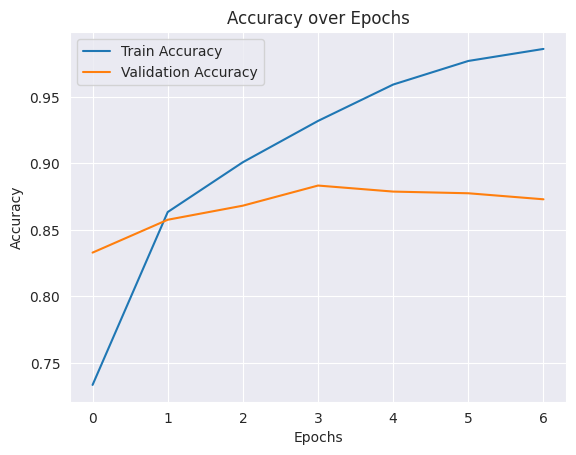

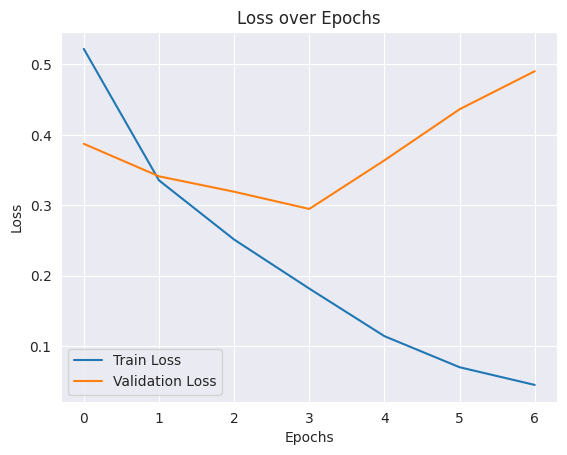

In [23]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

310/310 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Accuracy: 0.8898860542502773

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      4940
           1       0.87      0.92      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



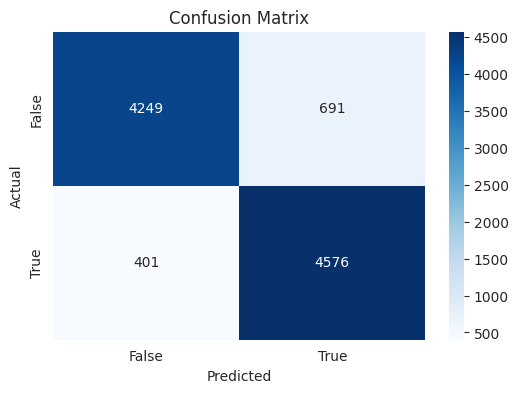

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(cleaned['label'].unique()),
            yticklabels=sorted(cleaned['label'].unique()))

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
import pickle

# 1. Save the trained LSTM model
model.save('sentiment_lstm_word2vec_model.h5')

# 2. Save the Word2Vec model
word2vec_model.save('word2vec_model.bin')

# 3. Save the vocabulary mapping and max_length
model_config = {
    'vocab': vocab,
    'vocab_size': vocab_size,
    'max_length': max_length,
    'embedding_dim': embedding_dim
}

with open('lstm_word2vec_model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

print("All models and configurations saved successfully!")

All models and configurations saved successfully!
